In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

from System.system import System, Agent

In [2]:
def identity(arr):
    return arr

# Refactored Code

## System_01 - 1D Flipflop

In [3]:
sys_01 = System(np.array([[0.0],[1.0]]),
                ((identity, [1]), (identity, [0])),
               verbose=True)
sys_01.go(10)

input chan idxs: []


array([[[0.],
        [1.]],

       [[1.],
        [0.]],

       [[0.],
        [1.]],

       [[1.],
        [0.]],

       [[0.],
        [1.]],

       [[1.],
        [0.]],

       [[0.],
        [1.]],

       [[1.],
        [0.]],

       [[0.],
        [1.]],

       [[1.],
        [0.]]])

## System_02 - 3D Flipflop

In [4]:
sys_02 = System(np.array([[0.0,1.0,0.0],[1.0,1.0,0.0]]),
                ((identity, [1]), (identity, [0])),
               verbose=True)
sys_02.go(10)

input chan idxs: []


array([[[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]],

       [[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]],

       [[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]],

       [[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]],

       [[0., 1., 0.],
        [1., 1., 0.]],

       [[1., 1., 0.],
        [0., 1., 0.]]])

## System_03 - 3D Multi-system Queue

In [5]:
sys_03a = System(np.array([[0.0,0.0,0.0],[0.0,0.0,0.0],[0.0,0.0,0.0],[0.0,0.0,0.0]]),
                (None, (identity, [0]), (identity, [1]), (identity, [2])),
                output_channel_idx=3,
                verbose=True)

sys_03b = System(np.array([[0.0,0.0,0.0],[0.0,0.0,0.0],[0.0,0.0,0.0],[0.0,0.0,0.0]]),
                ((None), (identity, [0]), (identity, [1]), (identity, [2])),
                output_channel_idx=3,
                verbose=True)

sys_03c = System(np.array([[0.0,2.0,0.0],[1.0,1.0,0.0]]),
                ((sys_03a, [1]), (sys_03b, [0])),
               verbose=True)
sys_03c.go(10)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


array([[[0., 2., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [0., 2., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [0., 2., 0.]],

       [[1., 1., 0.],
        [0., 2., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 2., 0.],
        [0., 0., 0.],
        [1., 1., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 2., 0.],
        [0., 0., 0.],
        [1., 1., 0.]],

       [[0., 2., 0.],
        [1., 1., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [1., 1., 0

## System_04 - (Conformist) Agent with Plant (n=1)

In [3]:
np.random.seed(31415926)
n = 1

l_val = 1.0
a_val=0.4

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
motor_transform = np.random.rand(n,n) 
def effect(error, motor_state):
    lambda_val = l_val
    m_e = error @  motor_transform
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    # if ref_bounds is not None:
    #     reference[reference > ref_bounds[1]] = ref_bounds[1]
    #     reference[reference < ref_bounds[0]] = ref_bounds[0]
    return reference
def feedback_false(error, reference, reference_init):
    return reference

# SYSTEM INIT
sys_04a = Agent(sense, compare, effect, move, feedback,
                n, reference_initial=np.full((1,n), 0.75),
                verbose=True)

 # -------------------------------------- #

# PLANT

T_scaler = 0.1
transition_matrix = np.random.rand(n,n) * T_scaler 
def plant_control(control_signal, state):
    output = control_signal @ transition_matrix + state
    return output
    
def plant_reflect(control_signal, state):
    output = control_signal @ transition_matrix
    return output

# SYSTEM INIT
sys_04b = System(np.zeros((2,n)),
                ((None), (plant_control, [0,1])),
                ["plant input", "plant output"],
                output_channel_idx=1,
                verbose=True)

 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_04c = System(np.random.rand(2,n),
                ((sys_04b, [1]), (sys_04a, [0])),
                ["agent input / plant behavior", "plant input / motor signal"],
               verbose=True)
sysout = sys_04c.go(1000)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


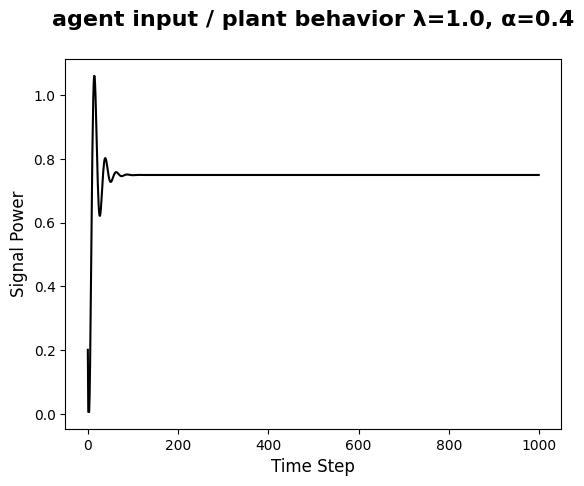

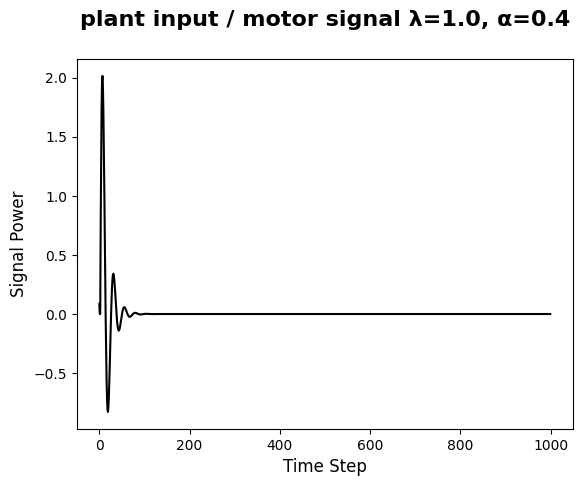

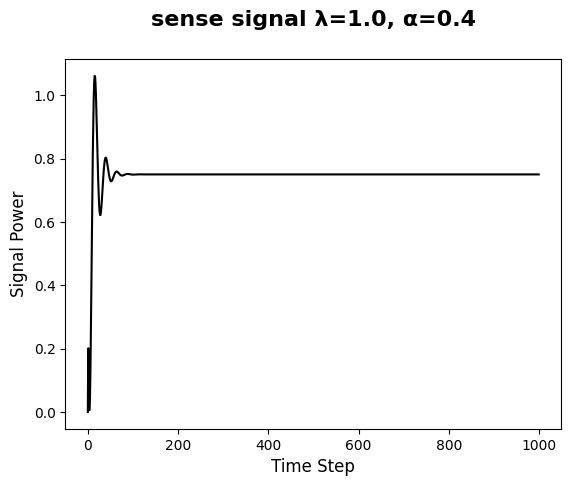

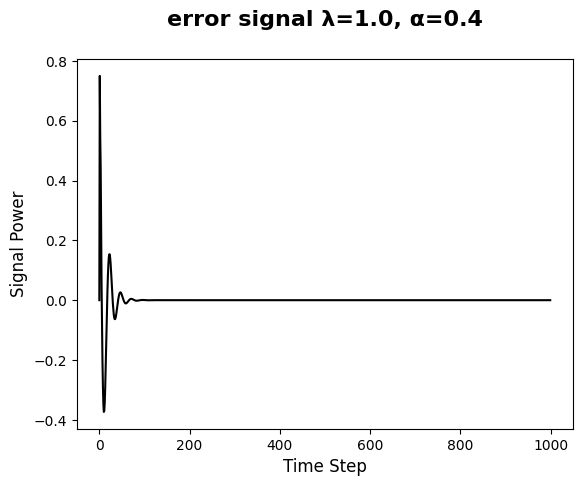

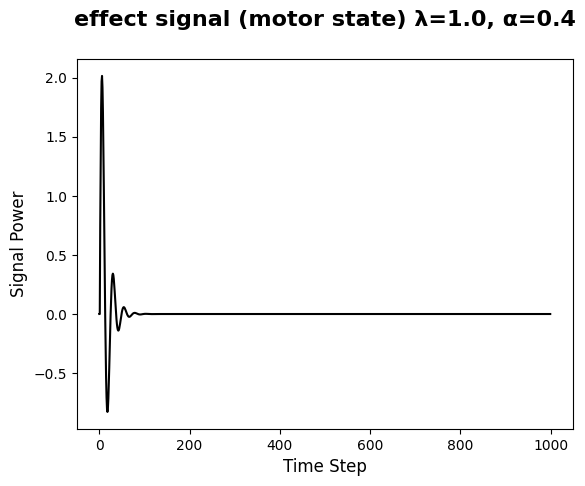

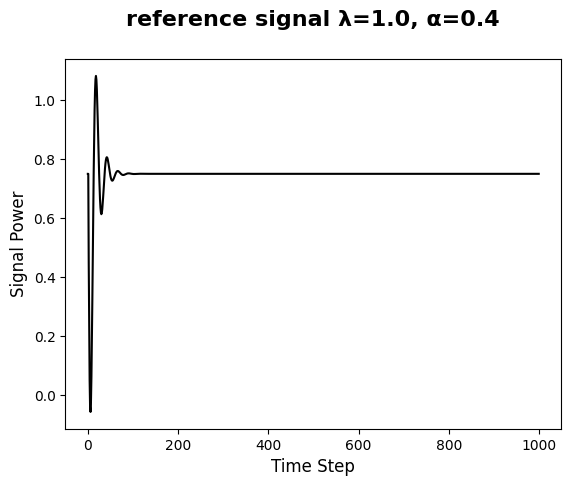

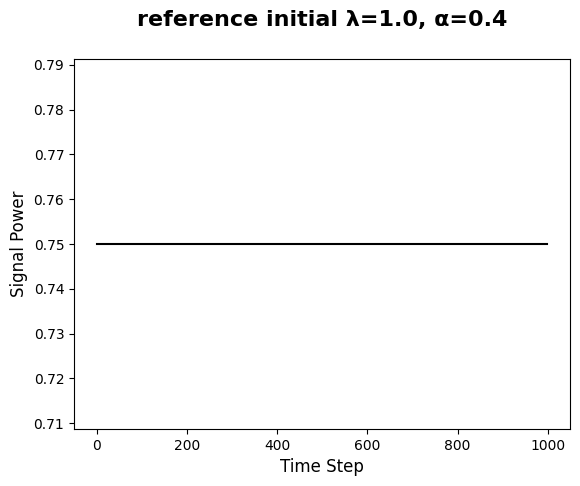

In [273]:
dcn = sys_04c.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-')
    plt.title(dcn[i] + f" λ={np.mean(l_val):.2}, α={a_val}", weight='bold', fontsize=16, pad=24)
    plt.ylabel("Signal Power", fontsize=12)
    plt.xlabel("Time Step", fontsize=12)
    plt.savefig(f"PICS/systems/system04_{dcn[i].replace("/","").replace(" ","-")}_l-{l_val}_a-{a_val}.png")
    plt.show()

In [283]:
def cont(l=1.0, a=0.2, seed=None, ts=100):
    if seed is None:
        np.random.seed(31415926)
    if ts == 100:
        tstag = ""
    else:
        tstag = "l"
    n = 1
    
    l_val = l
    a_val = a

    def sysinit():
        # AGENT
        # MAIN FEEDBACK CHAIN
        
        # get the state observation (behaviors of others)
        def sense(inputs):
            return inputs
        
        # contrast reference with observations (and potentially incorporate predictions from internal model)
        def compare(sensory_signal, reference):
            error = reference - sensory_signal
            return error
        
        # create a motor plan
        motor_transform = np.random.rand(n,n) 
        def effect(error, motor_state):
            lambda_val = l_val
            m_e = error @  motor_transform
            g_of_e_m = np.linalg.norm(error) * \
                (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
            next_motor_state = motor_state + lambda_val * g_of_e_m
            return next_motor_state
        
        # execute move
        def move(motor_signal):
            i = np.identity(motor_signal.shape[0])
            return motor_signal @ i
        
        # reference update via feedback
        def feedback(error, reference, reference_init):
            reference = reference - (error * a_val)
            # if ref_bounds is not None:
            #     reference[reference > ref_bounds[1]] = ref_bounds[1]
            #     reference[reference < ref_bounds[0]] = ref_bounds[0]
            return reference
        def feedback_false(error, reference, reference_init):
            return reference
        
        # SYSTEM INIT
        sys_04a = Agent(sense, compare, effect, move, feedback,
                        n, reference_initial=np.full((1,n), 0.75),
                        verbose=False)
        
         # -------------------------------------- #
        
        # PLANT
        
        T_scaler = 0.1
        transition_matrix = np.random.rand(n,n) * T_scaler 
        def plant_control(control_signal, state):
            output = control_signal @ transition_matrix + state
            return output
        
        # SYSTEM INIT
        sys_04b = System(np.zeros((2,n)),
                        ((None), (plant_control, [0,1])),
                        ["plant input", "plant output"],
                        output_channel_idx=1,
                        verbose=False)
        
         # -------------------------------------- #
        
        # TOTAL SYSTEM INIT
        sys_04c = System(np.random.rand(2,n),
                        ((sys_04b, [1]), (sys_04a, [0])),
                        ["agent input / plant behavior", "plant input / motor signal"],
                       verbose=False)
        sysout = sys_04c.go(ts)
        return (sysout, sys_04c.deep_channel_names())
    if seed is None:
        sysout, dcn = sysinit()
        comptag = ""
        fade = 2
    else:
        sysout_list = []
        for s in seed:
            np.random.seed(s)
            so, dcn = sysinit()
            sysout_list.append(so)
        sysout = np.concatenate(sysout_list, axis=2)
        comptag = "c"
        fade = len(seed)
        # raise NotImplementedError(":)")
    for i in range(sysout.shape[1]):
        plt.clf()
        plt.plot(sysout[:,i,:], 'k-', alpha=2/fade)
        plt.title(dcn[i] + f" λ={np.mean(l_val):.1}, α={a_val:.1f}", weight='bold', fontsize=16, pad=24)
        plt.ylabel("Signal Power", fontsize=12)
        plt.xlabel("Time Step", fontsize=12)
        plt.savefig(f"PICS/systems/system04{comptag}{tstag}_{dcn[i].replace("/","").replace(" ","-")}" + 
                    f"_l-{l_val:.1f}_a-{a_val:.1f}.png")
        # plt.show()

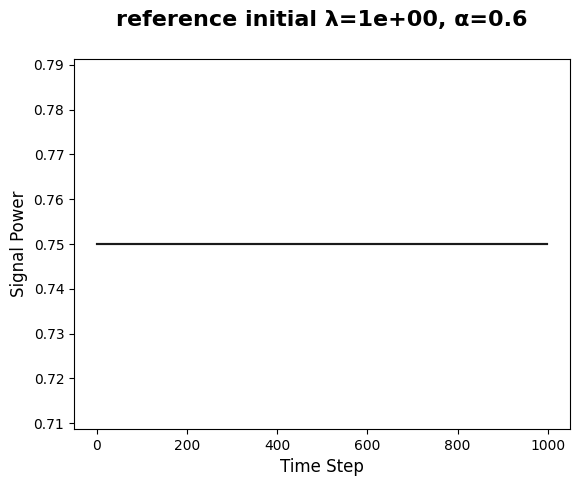

In [288]:
# for l in np.linspace(0,1,6):
#     for a in np.linspace(0,1,6):
#         print((l,a))
#         cont(l, a, seed=np.random.randint(1, 100000000, 20))
# cont(l=1, a=0.6, seed=np.random.randint(1, 100000000, 20), ts=1000)

## System_05 - (Conformist) Agent with Plant (n=10)

In [160]:
n = 20

l_val = 0.05 # + np.random.rand(n) * 0.01
a_val = 0.4

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
motor_transform = np.random.rand(n,n)
# motor_transform = np.eye(n,n)
def effect(error, motor_state):
    lambda_val = l_val
    m_e = error @  motor_transform
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    # if ref_bounds is not None:
    #     reference[reference > ref_bounds[1]] = ref_bounds[1]
    #     reference[reference < ref_bounds[0]] = ref_bounds[0]
    return reference

# SYSTEM INIT
sys_05a = Agent(sense, compare, effect, move, feedback,
                n,
                # motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.9),
                verbose=True)

 # -------------------------------------- #

# PLANT

T_scaler = .1
transition_matrix = np.random.rand(n,n) * T_scaler 
def plant_control(control_signal, state):
    output = control_signal @ transition_matrix + state
    return output

# SYSTEM INIT
sys_05b = System(np.zeros((2,n)),
                ((None), (plant_control, [0,1])),
                ["plant input", "plant output"],
                output_channel_idx=1,
                verbose=True)

 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_05c = System(np.random.rand(2,n),
                ((sys_05b, [1]), (sys_05a, [0])),
                ["agent input", "plant input / agent behavior"],
               verbose=True)
sysout = sys_05c.go(400)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


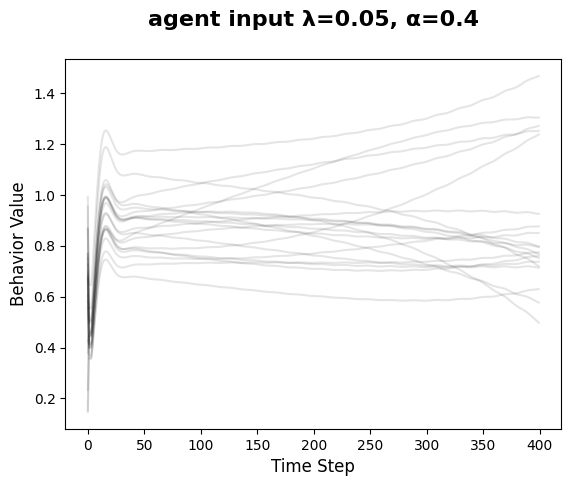

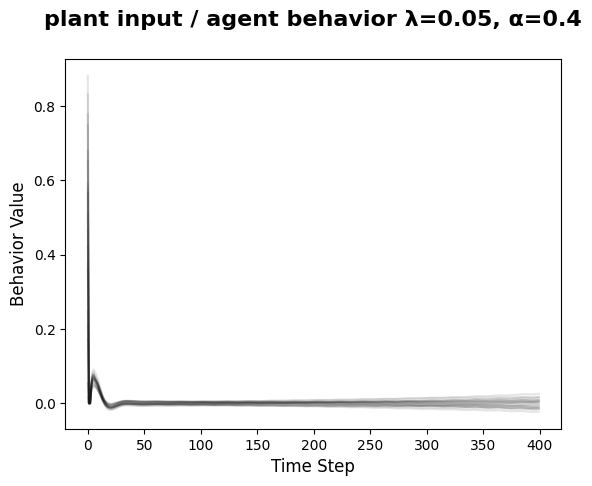

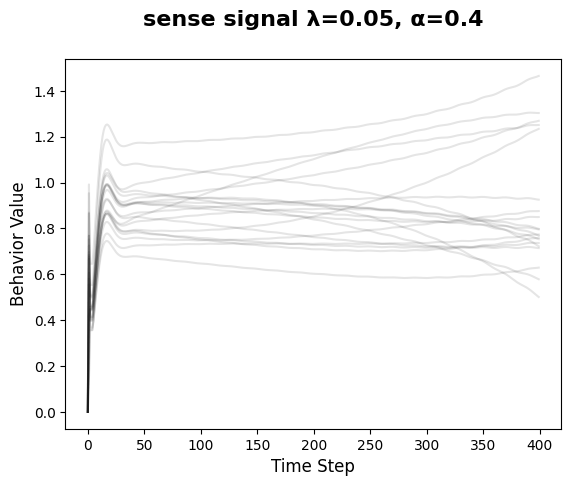

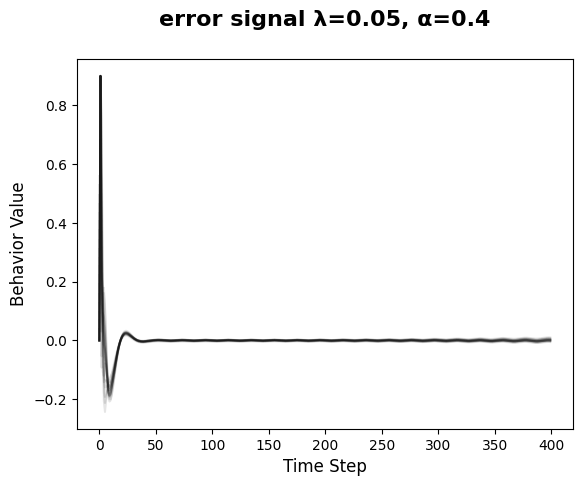

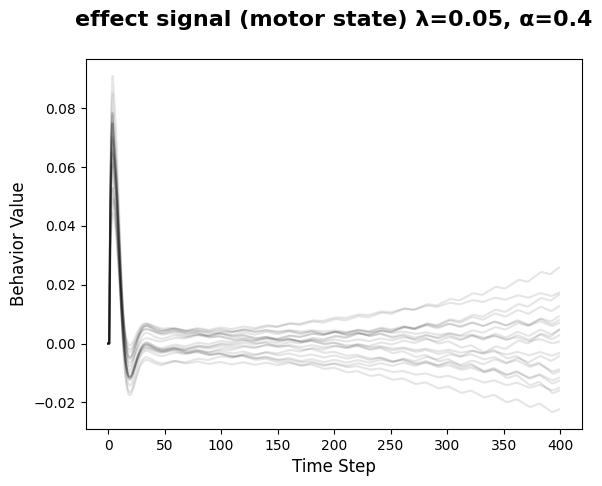

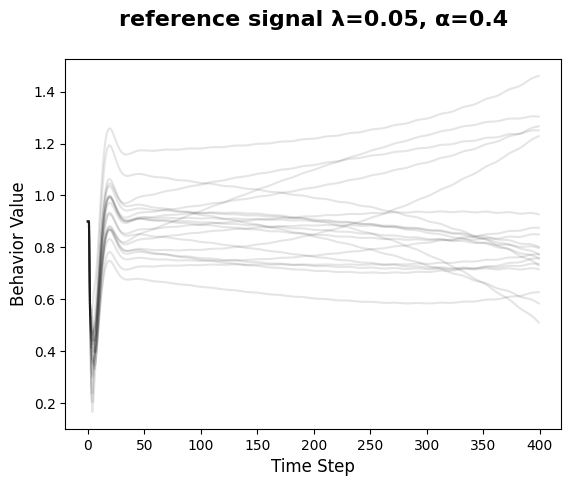

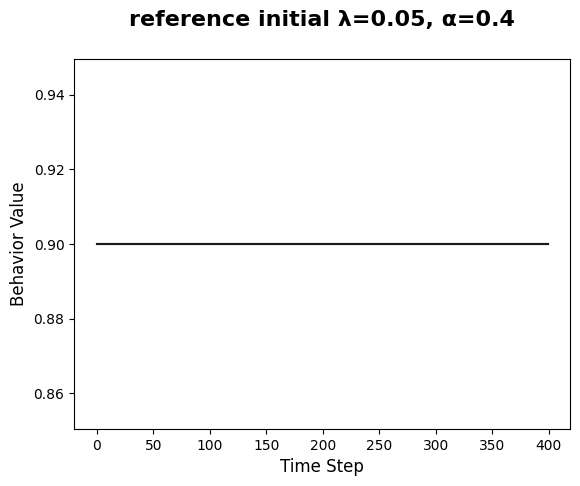

In [161]:
dcn = sys_05c.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i] + f" λ={np.mean(l_val):.2}, α={a_val}", weight='bold', fontsize=16, pad=24)
    plt.ylabel("Behavior Value", fontsize=12)
    plt.xlabel("Time Step", fontsize=12)
    plt.show()

In [313]:
def cont02(l=1.0, a=0.2, seed=None, ts=100):
    if seed is None:
        np.random.seed(31415926)
    if ts == 100:
        tstag = ""
    else:
        tstag = "l"
    n = 20
    
    l_val = l
    a_val = a

    def sysinit():
        # AGENT
        # MAIN FEEDBACK CHAIN
        
        # get the state observation (behaviors of others)
        def sense(inputs):
            return inputs
        
        # contrast reference with observations (and potentially incorporate predictions from internal model)
        def compare(sensory_signal, reference):
            error = reference - sensory_signal
            return error
        
        # create a motor plan
        motor_transform = np.random.rand(n,n) 
        def effect(error, motor_state):
            lambda_val = l_val
            m_e = error @  motor_transform
            g_of_e_m = np.linalg.norm(error) * \
                (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
            next_motor_state = motor_state + lambda_val * g_of_e_m
            return next_motor_state
        
        # execute move
        def move(motor_signal):
            i = np.identity(motor_signal.shape[0])
            return motor_signal @ i
        
        # reference update via feedback
        def feedback(error, reference, reference_init):
            reference = reference - (error * a_val)
            # if ref_bounds is not None:
            #     reference[reference > ref_bounds[1]] = ref_bounds[1]
            #     reference[reference < ref_bounds[0]] = ref_bounds[0]
            return reference
        def feedback_false(error, reference, reference_init):
            return reference
        
        # SYSTEM INIT
        sys_05a = Agent(sense, compare, effect, move, feedback,
                        n, reference_initial=np.full((1,n), 0.75),
                        verbose=False)
        
         # -------------------------------------- #
        
        # PLANT
        
        T_scaler = 0.1
        transition_matrix = np.random.rand(n,n) * T_scaler 
        def plant_control(control_signal, state):
            output = control_signal @ transition_matrix + state
            return output
        
        # SYSTEM INIT
        sys_05b = System(np.zeros((2,n)),
                        ((None), (plant_control, [0,1])),
                        ["plant input", "plant output"],
                        output_channel_idx=1,
                        verbose=False)
        
         # -------------------------------------- #
        
        # TOTAL SYSTEM INIT
        sys_05c = System(np.random.rand(2,n),
                        ((sys_05b, [1]), (sys_05a, [0])),
                        ["agent input / plant behavior", "plant input / motor signal"],
                       verbose=False)
        sysout = sys_05c.go(ts)
        return (sysout, sys_04c.deep_channel_names())
    if seed is None:
        sysout, dcn = sysinit()
        comptag = ""
        fade = n
    else:
        sysout_list = []
        for s in seed:
            np.random.seed(s)
            so, dcn = sysinit()
            sysout_list.append(np.mean(so, axis=2))
        sysout = np.stack(sysout_list, axis=2)
        comptag = "c"
        fade = len(seed)
        # raise NotImplementedError(":)")
    for i in range(sysout.shape[1]):
        plt.clf()
        plt.plot(sysout[:,i,:], 'k-', alpha=2/fade)
        plt.title(dcn[i] + f" λ={np.mean(l_val):.2}, α={a_val:.1f}", weight='bold', fontsize=16, pad=24)
        plt.ylabel("Signal Power", fontsize=12)
        plt.xlabel("Time Step", fontsize=12)
        plt.savefig(f"PICS/systems/system05{comptag}{tstag}_{dcn[i].replace("/","").replace(" ","-")}" + 
                    f"_l-{l_val:.2f}_a-{a_val:.1f}.png")
        # plt.show()

(np.float64(0.0), np.float64(0.0))
(np.float64(0.0), np.float64(0.2))
(np.float64(0.0), np.float64(0.4))
(np.float64(0.0), np.float64(0.6000000000000001))
(np.float64(0.0), np.float64(0.8))
(np.float64(0.0), np.float64(1.0))
(np.float64(0.05), np.float64(0.0))
(np.float64(0.05), np.float64(0.2))
(np.float64(0.05), np.float64(0.4))
(np.float64(0.05), np.float64(0.6000000000000001))
(np.float64(0.05), np.float64(0.8))
(np.float64(0.05), np.float64(1.0))
(np.float64(0.1), np.float64(0.0))
(np.float64(0.1), np.float64(0.2))
(np.float64(0.1), np.float64(0.4))
(np.float64(0.1), np.float64(0.6000000000000001))
(np.float64(0.1), np.float64(0.8))
(np.float64(0.1), np.float64(1.0))
(np.float64(0.15000000000000002), np.float64(0.0))
(np.float64(0.15000000000000002), np.float64(0.2))
(np.float64(0.15000000000000002), np.float64(0.4))
(np.float64(0.15000000000000002), np.float64(0.6000000000000001))
(np.float64(0.15000000000000002), np.float64(0.8))
(np.float64(0.15000000000000002), np.float64(1.0)

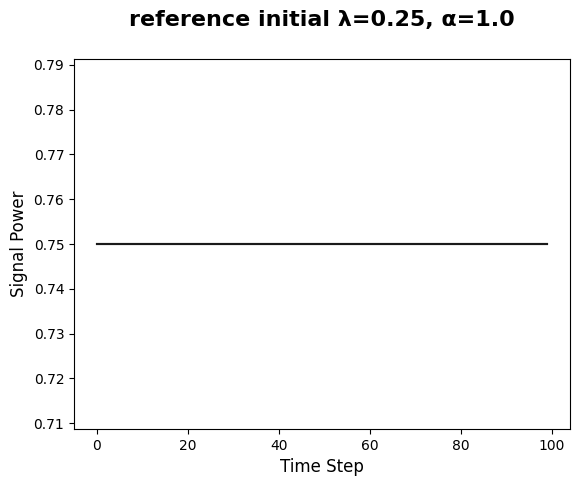

In [323]:
for l in np.linspace(0,0.25,6):
    for a in np.linspace(0,1,6):
        print((l,a))
        # cont02(l, a)
        # cont02(l, a, seed=np.random.randint(1, 100000000, 20))
# cont02(l=0.05, a=0.99, ts=1000)
# cont02(l=1, a=0.6, seed=np.random.randint(1, 100000000, 20), ts=1000)

## System_06 - Dual Agent (n=10)

In [59]:
n = 10

l_val = 0.01

a_val = 0.8
a_val_pw = 0.8

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
motor_transform = np.random.rand(n,n)
def effect(error, motor_state):
    lambda_val = l_val
    m_e = error @  motor_transform
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    return reference
# does not adjust reference
def feedback_false(error, reference, reference_init):
    return reference
# peacewise feedback
def feedback_piecewise(error, reference, reference_init):
    mu = 0.000000010
    sqr_error = np.square(error)
    msq_error  = np.mean(sqr_error)
    # print(msq_error)
    if msq_error < mu:
        return reference_init
    else:
        return reference - (error * a_val_pw)

# SYSTEM INIT
sys_06a = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), -0.5),
                name="Agent_1 (conformist)",
                verbose=True)

# ------ #

# SYSTEM INIT
sys_06b = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (conformist)",
                verbose=True)

# SYSTEM INIT
sys_06c = Agent(sense, compare, effect, move, feedback_false,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (stubborn)",
                verbose=True)

# SYSTEM INIT
sys_06d = Agent(sense, compare, effect, move, feedback_piecewise,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (hybrid)",
                verbose=True)

 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_06_total = System(np.random.rand(2,n),
                ((sys_06d, [1]), (sys_06a, [0])),
                ["Agent_1 input", "Agent_2 input"],
               verbose=True)

sysout = sys_06_total.go(100)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0]
input chan idxs: []


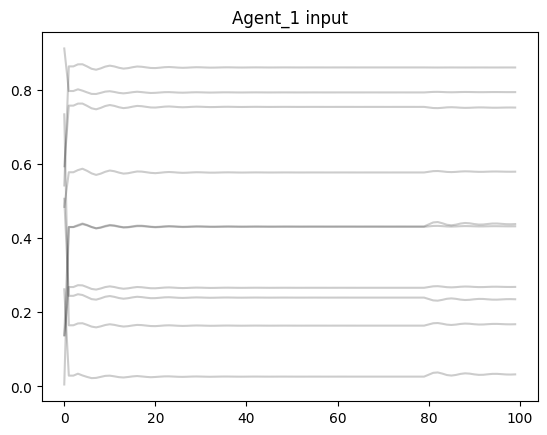

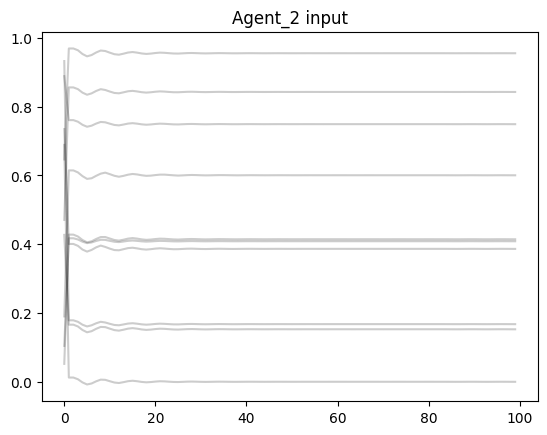

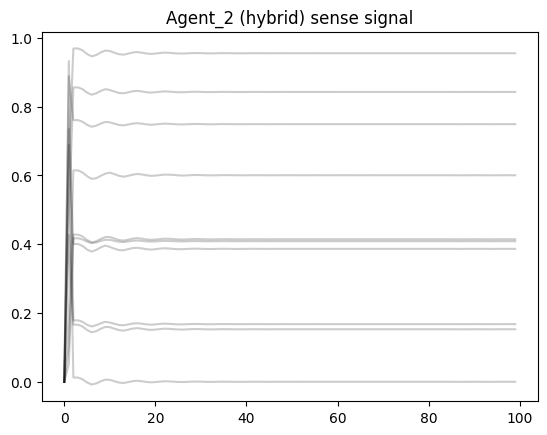

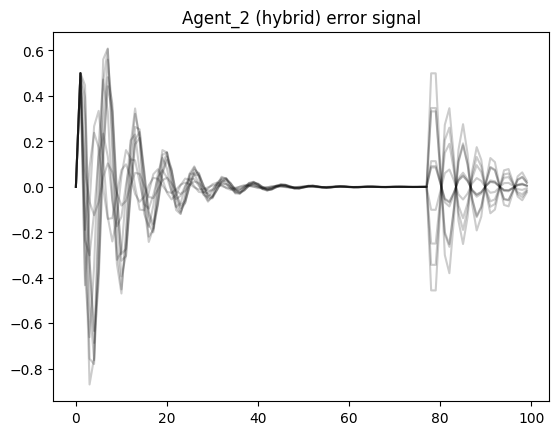

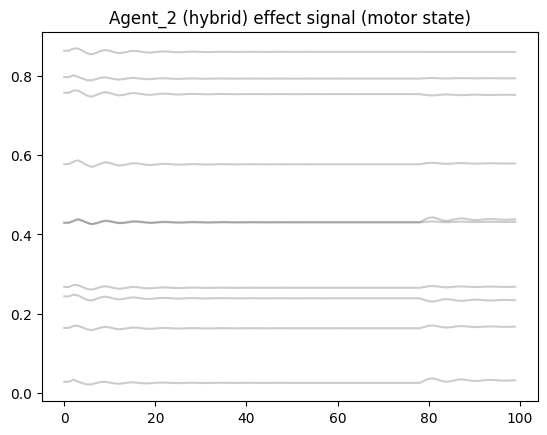

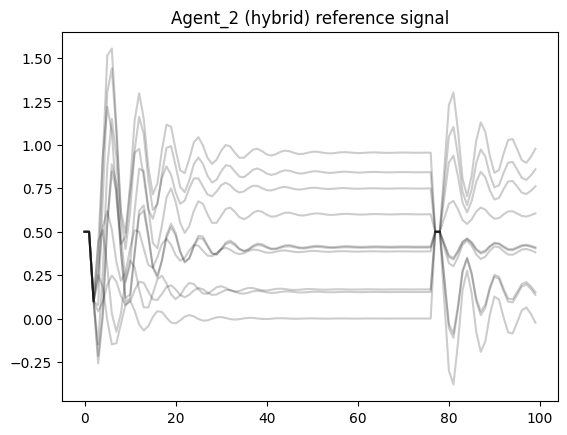

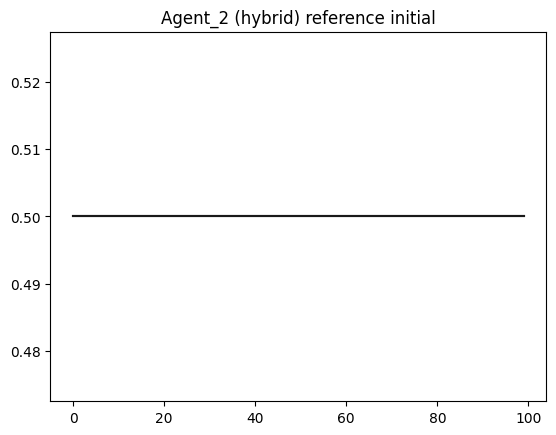

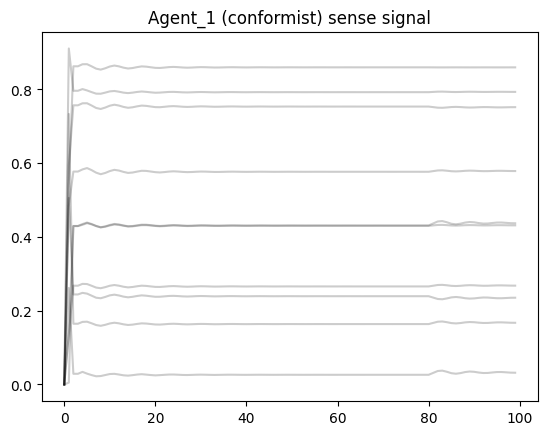

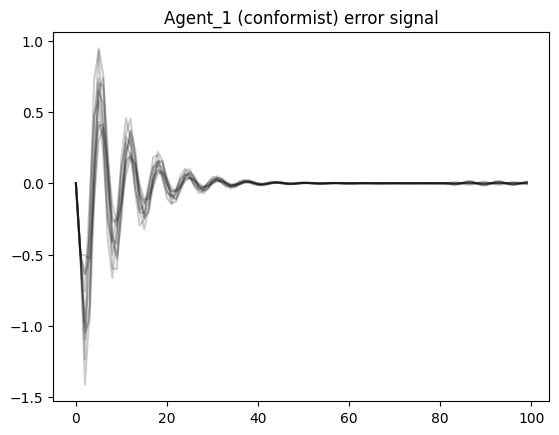

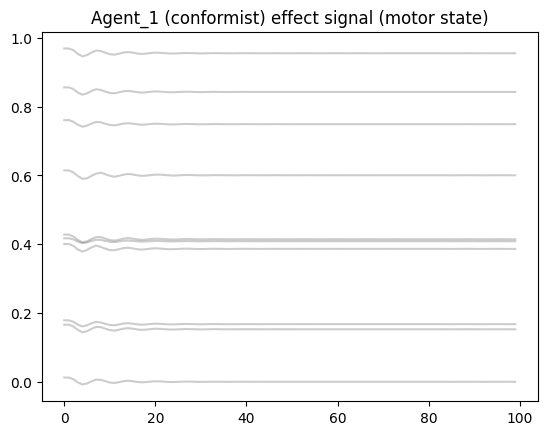

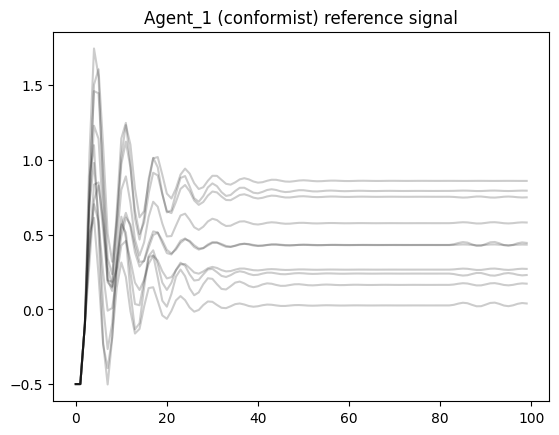

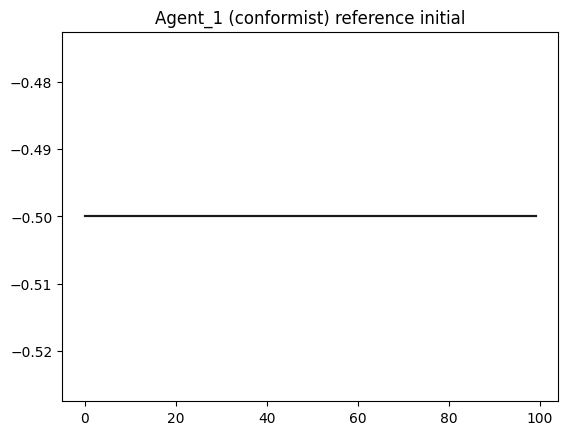

In [60]:
dcn = sys_06_total.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i])
    plt.show()

In [39]:
def cont03(l=0.01, a=0.1, apw=0.1, seed=None, ts=100, mode="dual"):
    if seed is None:
        np.random.seed(31415926)
    if np.log10(ts) <= 2:
        tstag = ""
    else:
        tstag = int(np.log10(ts) - 2) * "l"
    n = 20
    
    l_val = l
    
    a_val = a
    a_val_pw = apw
    
    def sysinit():
        # AGENT
        # MAIN FEEDBACK CHAIN
        
        # get the state observation (behaviors of others)
        def sense(inputs):
            return inputs
        
        # contrast reference with observations (and potentially incorporate predictions from internal model)
        def compare(sensory_signal, reference):
            error = reference - sensory_signal
            return error
        
        # create a motor plan
        motor_transform = np.random.rand(n,n)
        def effect(error, motor_state):
            lambda_val = l_val
            m_e = error @  motor_transform
            g_of_e_m = np.linalg.norm(error) * \
                (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
            next_motor_state = motor_state + lambda_val * g_of_e_m
            return next_motor_state
        
        # execute move
        def move(motor_signal):
            i = np.identity(motor_signal.shape[0])
            return motor_signal @ i
        
        # reference update via feedback
        def feedback(error, reference, reference_init):
            reference = reference - (error * a_val)
            return reference
        # does not adjust reference
        def feedback_false(error, reference, reference_init):
            return reference
        # peacewise feedback
        def feedback_piecewise(error, reference, reference_init):
            mu = 0.0010
            sqr_error = np.square(error)
            msq_error  = np.mean(sqr_error)
            # print(msq_error)
            if msq_error < mu:
                return reference_init
            else:
                return reference - (error * a_val_pw)
        
        # SYSTEM INIT
        sys_06a = Agent(sense, compare, effect, move, feedback,
                        n, 
                        motor_prior=np.random.rand(1,n),
                        reference_initial=np.full((1,n), -0.5),
                        name="Agent_1 (conformist)",
                        verbose=False)
        
        # ------ #

        if mode == "conformist":
            fbfn = feedback
        elif mode == "stubborn":
            fbfn = feedback_false
        elif mode == "hybrid":
            fbfn = feedback_piecewise
        else:
            raise ValueError("Not a valid mode")
        
        # SYSTEM INIT
        sys_06b = Agent(sense, compare, effect, move, fbfn,
                        n, 
                        motor_prior=np.random.rand(1,n),
                        reference_initial=np.full((1,n), 0.5),
                        name=f"Agent_2 ({mode})",
                        verbose=False)
        
         # -------------------------------------- #
        
        # TOTAL SYSTEM INIT
        sys_06_total = System(np.random.rand(2,n),
                        ((sys_06b, [1]), (sys_06a, [0])),
                        ["Agent_1 input", "Agent_2 input"],
                       verbose=False)
        
        sysout = sys_06_total.go(ts)
        dcn = sys_06_total.deep_channel_names()
        return (sysout, sys_06_total.deep_channel_names())
    if seed is None:
        sysout, dcn = sysinit()
        comptag = ""
        fade = n
    else:
        sysout_list = []
        for s in seed:
            np.random.seed(s)
            so, dcn = sysinit()
            sysout_list.append(np.mean(so, axis=2))
        sysout = np.stack(sysout_list, axis=2)
        comptag = "c"
        fade = len(seed)
        # raise NotImplementedError(":)")
    # print(dcn)
    for i in range(sysout.shape[1]):
        plt.clf()
        plt.plot(sysout[:,i,:], 'k-', alpha=2/fade)
        plt.title(dcn[i] + f" λ={np.mean(l_val):.2}, α={a_val:.1f}", weight='bold', fontsize=12, pad=24)
        plt.ylabel("Signal Power", fontsize=12)
        plt.xlabel("Time Step", fontsize=12)
        plt.savefig(f"PICS/systems/system06{comptag}{tstag}_mode-{mode[0]}_{dcn[i].replace("/","").replace(" ","-")}" + 
                    f"_l-{l_val:.2f}_a-{a_val:.1f}.png")
        # plt.show()

(np.float64(0.0), np.float64(0.0))
(np.float64(0.0), np.float64(0.2))
(np.float64(0.0), np.float64(0.4))
(np.float64(0.0), np.float64(0.6000000000000001))
(np.float64(0.0), np.float64(0.8))
(np.float64(0.0), np.float64(1.0))
(np.float64(0.05), np.float64(0.0))
(np.float64(0.05), np.float64(0.2))
(np.float64(0.05), np.float64(0.4))
(np.float64(0.05), np.float64(0.6000000000000001))
(np.float64(0.05), np.float64(0.8))
(np.float64(0.05), np.float64(1.0))
(np.float64(0.1), np.float64(0.0))
(np.float64(0.1), np.float64(0.2))
(np.float64(0.1), np.float64(0.4))
(np.float64(0.1), np.float64(0.6000000000000001))
(np.float64(0.1), np.float64(0.8))
(np.float64(0.1), np.float64(1.0))
(np.float64(0.15000000000000002), np.float64(0.0))
(np.float64(0.15000000000000002), np.float64(0.2))
(np.float64(0.15000000000000002), np.float64(0.4))
(np.float64(0.15000000000000002), np.float64(0.6000000000000001))
(np.float64(0.15000000000000002), np.float64(0.8))
(np.float64(0.15000000000000002), np.float64(1.0)

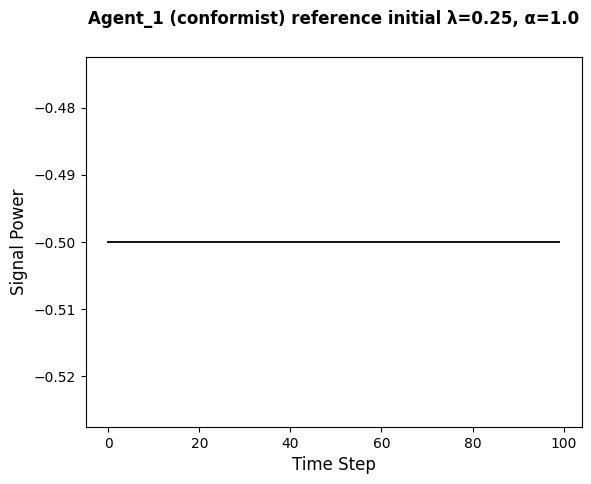

In [42]:
for l in np.linspace(0,0.25,6):
    for a in np.linspace(0,1,6):
        print((l,a))
        # cont03(l, a, a, mode="hybrid")
        # cont03(l, a, a, mode="hybrid", seed=np.random.randint(1, 100000000, 50))
# cont03(l=0.03, a=0.8, apw=0.8, mode="hybrid", ts=10000)
# cont02(l=1, a=0.6, seed=np.random.randint(1, 100000000, 20), ts=1000)

## System_07 - Dual Agent + Extra (n=10)

In [73]:
n = 10

l_val = 0.01
l_val2 = 0.01

a_val = 0.2
a_val2 = 0.2

# AGENT
# MAIN FEEDBACK CHAIN

# get the state observation (behaviors of others)
def sense(inputs):
    return inputs

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference):
    error = reference - sensory_signal
    return error

# create a motor plan
motor_transform = np.random.rand(n,n)
def effect(error, motor_state):
    lambda_val = l_val
    m_e = error @  motor_transform
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

motor_transform2 = np.random.rand(n,n)
def effect2(error, motor_state):
    lambda_val = l_val2
    m_e = error @  motor_transform2
    g_of_e_m = np.linalg.norm(error) * \
        (m_e / (np.linalg.norm(m_e) + sys.float_info.min))
    next_motor_state = motor_state + lambda_val * g_of_e_m
    return next_motor_state

# execute move
def move(motor_signal):
    i = np.identity(motor_signal.shape[0])
    return motor_signal @ i

# reference update via feedback
def feedback(error, reference, reference_init):
    reference = reference - (error * a_val)
    return reference
def feedback_2nd_order(error, reference, reference_init):
    reference = reference - (error * a_val2)
    return reference    
# does not adjust reference
def feedback_false(error, reference, reference_init):
    return reference
# peacewise feedback
def feedback_piecewise(error, reference, reference_init):
    mu = 0.0010
    sqr_error = np.square(error)
    msq_error  = np.mean(sqr_error)
    # print(msq_error)
    if msq_error < mu:
        return reference_init
    else:
        return reference - (error * a_val_pw)

# SYSTEM INIT
sys_07a = Agent(sense, compare, effect, move, feedback,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), -0.5),
                name="Agent_1 (conformist)",
                verbose=True)

# ------ #

# SYSTEM INIT
sys_07b = Agent(sense, compare, effect2, move, feedback_2nd_order,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (inner)",
                verbose=True)

sys_07bw = System(np.zeros((4,n)),
                (None, None, None, (sys_07b, [0])),
                ["Agent_2_i input", "_", "_", "Agent_2_i ouput"],
                output_channel_idx=3,
                verbose=True)


# SYSTEM INIT
sys_07c = Agent(sense, compare, effect, move, sys_07bw,
                n, 
                motor_prior=np.random.rand(1,n),
                reference_initial=np.full((1,n), 0.5),
                name="Agent_2 (outer)",
                verbose=True)


 # -------------------------------------- #

# TOTAL SYSTEM INIT
sys_07_total = System(np.random.rand(2,n),
                ((sys_07c, [1]), (sys_07a, [0])),
                ["Agent_1 input", "Agent_2 input"],
               verbose=True)

sysout = sys_07_total.go(100)

input chan idxs: [0]
input chan idxs: [0]
input chan idxs: [0, 1, 2]
input chan idxs: [0]
input chan idxs: []


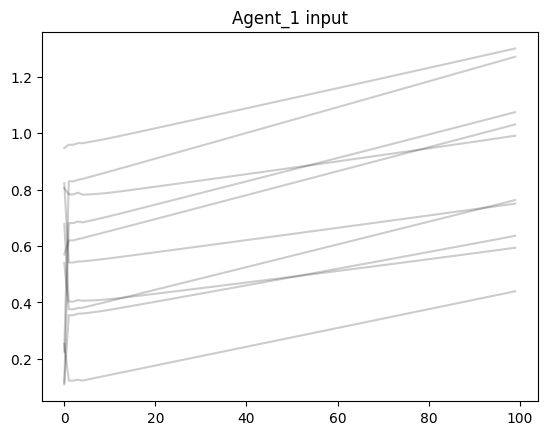

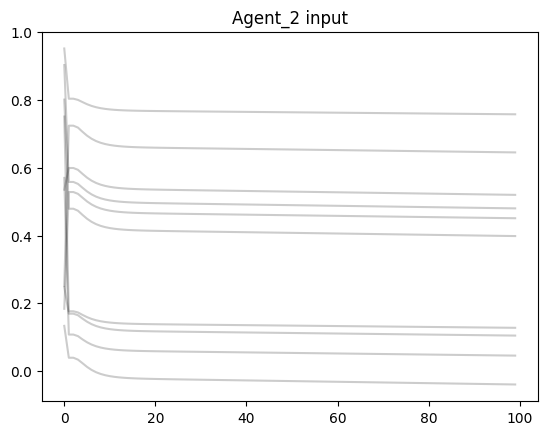

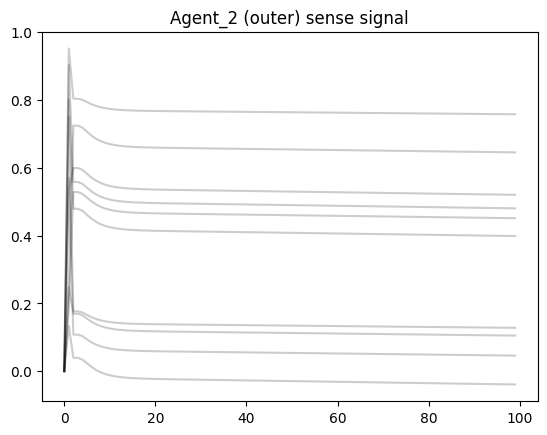

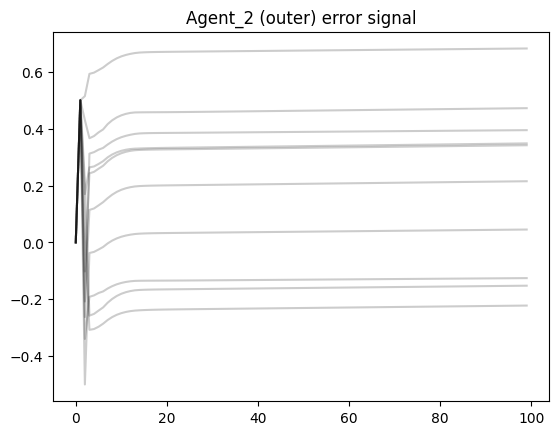

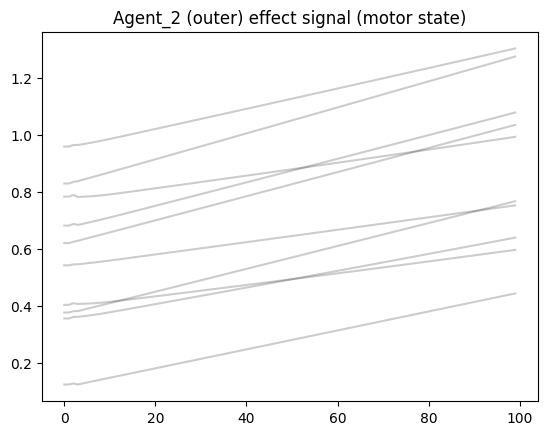

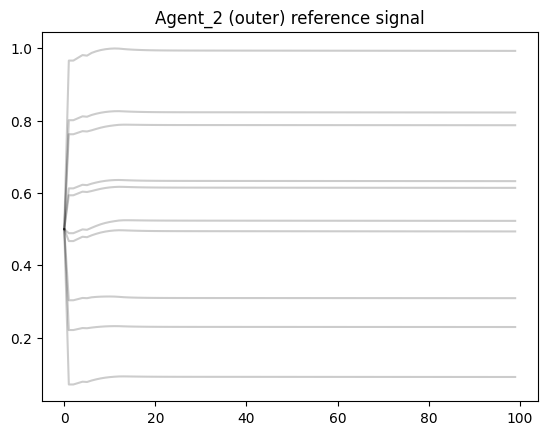

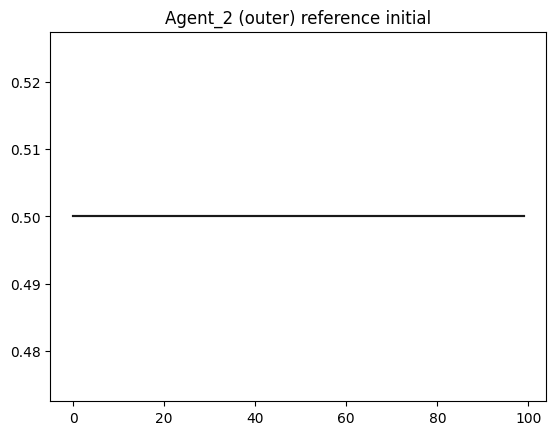

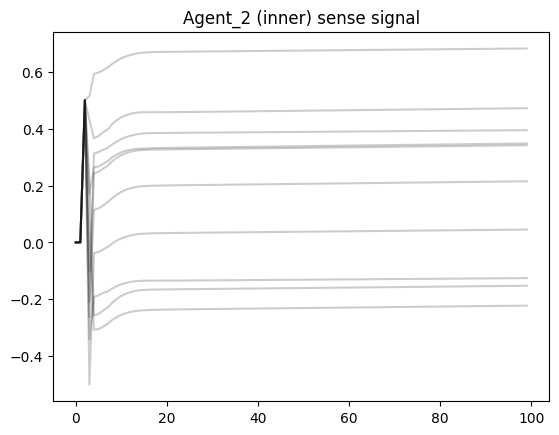

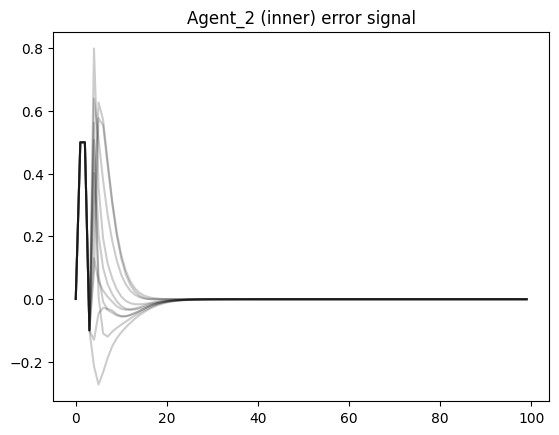

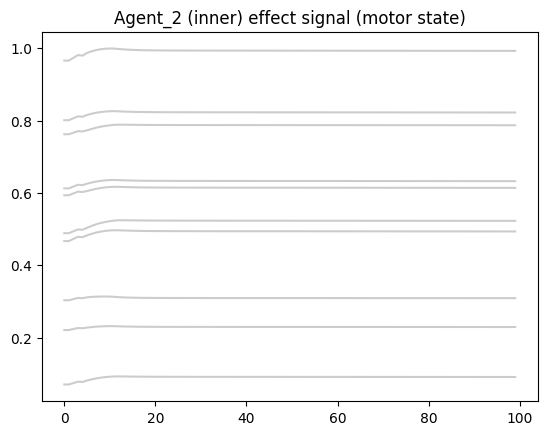

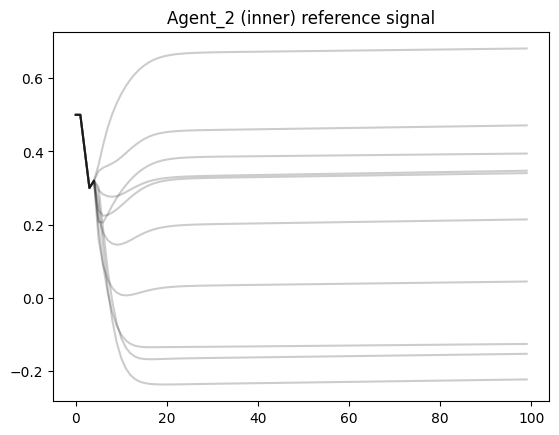

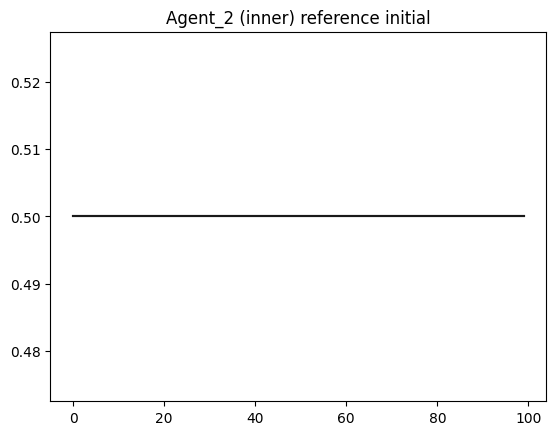

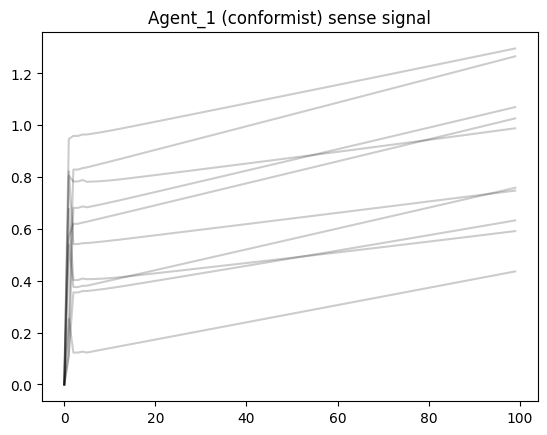

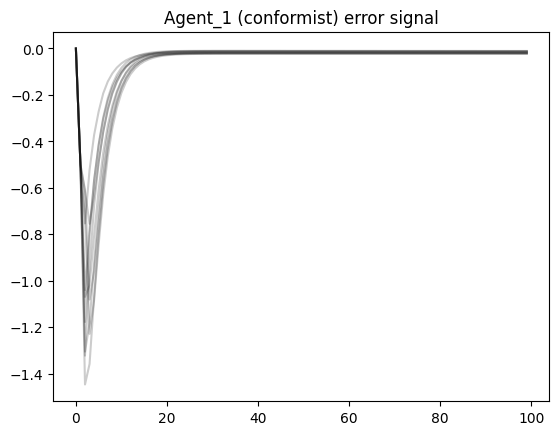

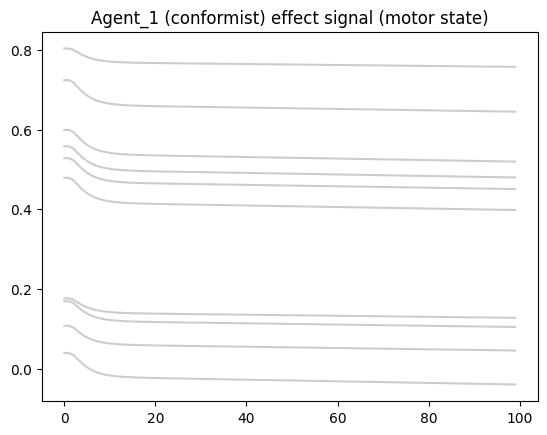

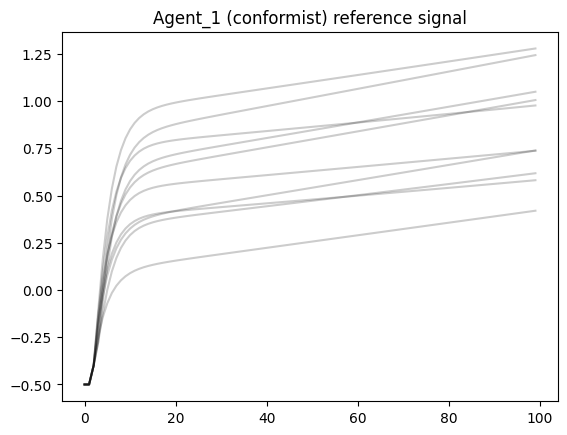

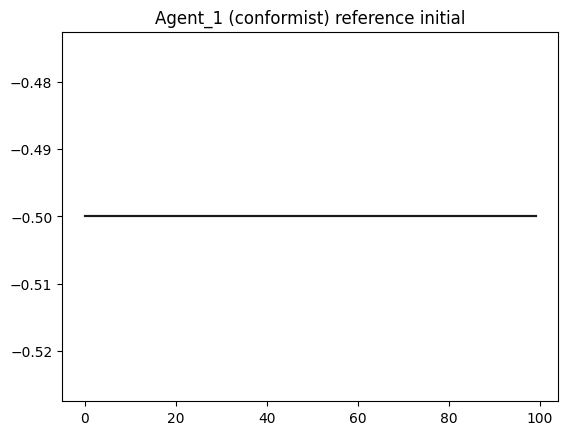

In [74]:
dcn = sys_07_total.deep_channel_names()
for i in range(sysout.shape[1]):
    plt.plot(sysout[:,i,:], 'k-', alpha=2/n)
    plt.title(dcn[i])
    plt.show()

In [165]:
def matrix_deriv(mat, features, steps):
  trans = mat.transpose()
  deriv = np.empty([features, steps-1])
  for feat in range(len(trans)):
    deriv[feat] = np.diff(trans[feat], 1)
  return deriv.transpose()

In [346]:
# seed = random.randrange(1000)
seed = 378
np.random.seed(seed)

behav_size = 50
sigmoid_k = 200000000000
sigmoid_b = 20
# behavioral matrix (maps previous behavior to future behavior commands - how should I behave?)
# behavioral matrix (maps previous behavior to future behavior commands - how should I behave?)
B1 = np.random.rand(behav_size, behav_size)
B2 = np.random.rand(behav_size, behav_size)
# B1 = np.array([[1]])
# B2 = np.array([[1]])

# state/system matrix (maps previous state to future state - how will others behave (give past behaviors)?)
A1 = np.random.rand(1, behav_size)
A2 = np.random.rand(1, behav_size)

# reference matrix (how do I expect/want others to behave? target values)
R1 = np.random.rand(1, behav_size)
R2 = np.random.rand(1, behav_size)

# Initial behavior
behav_1 = np.random.rand(1, behav_size)
behav_2 = np.random.rand(1, behav_size)

# transition matrix (maps control signal and previous state to current state - what behaviors do I enact given my intentions?)
# T1 = np.array([.05])
# T2 = np.array([.05])
T1 = np.array([.1])
T2 = np.array([.1])

color2 = [0.1,0.6,0.2, 0.7]
color2c = [0.2,0.9,0.3, 0.4]

# get the state observation (behaviors of others)
def sense(inputs):
    perception = inputs
    return perception

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference, prediction):
    error = reference - sensory_signal
    return error

# generate a control signal
def control(error, behavioral_model, previous_output):
    control_signal = chaotic_controller(behavioral_model, 0.00001, error)
    # print(error, control_signal)
    # print(error/control_signal)
    return control_signal

# dictates how control commands determine state transitions - i.e. behaviors
def transition(control_signal, transition_matrix, state):
    new_state = (transition_matrix * control_signal) + state
    new_state[new_state > 1] = 1
    new_state[new_state < 0] = 0.0001
    return new_state


# adjusts behavioral model to get closer to behavior given 
def control_update(error, behavioral_model, previous_output):
    # LMS algorithm
    learning_rate = 0.0
    #behavioral_model = behavioral_model + learning_rate * error * previous_output
    return behavioral_model

# adjusts reference given error
def reference_update_true(reference, error):
    k = 0.3
    reference = reference - (error * k)
    reference[reference > 1] = 1
    reference[reference < 0] = 0.0001
    return reference

# does not adjust reference
def reference_update_false(reference, error):
    k = 0
    reference = reference + (error * k)
    return reference

def reference_update_sigmoid(reference, error):
    # reference = (matrix_sigmoid(error)-1)*(R1) + matrix_sigmoid(error)*(reference + error)
    sqr_error = np.square(error)
    reference = shifted_sigmoid(sqr_error, sigmoid_k, sigmoid_b)*(reference - error) + (1-shifted_sigmoid(sqr_error, sigmoid_k, sigmoid_b))*(R1)
    # k = 0.1
    # k =  zero_sigmoid(error)
    # reference = reference - (error * k)
    return reference

# generate predictions on next state
def imc(system_estimate, previous_state, behavioral_model, previous_output):
    # actual estimate
    state = (system_estimate * previous_state) + (behavioral_model * previous_output)
    return state

# adjust system estimate to infer observations given my behavior
def imc_update(inputs, system_estimate, previous_behavior, behavioral_model, previous_state, learning_rate):
    # actual estimate
    #curr_system_est = (system_estimate @ previous_state) + (behavioral_model @ previous_behavior)
    #error = curr_system_est - inputs
    #learning_rate = 0.01
    #system_estimate = system_estimate + learning_rate * error * previous_behavior
    return system_estimate

plant1 = Plant(transition_matrix=T1, transition_function=transition, state=behav_1)
plant2 = Plant(transition_matrix=T2, transition_function=transition, state=behav_2)

conformist1 = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_true,
controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
system_estimate=A1, reference=R1, init_behavior=behav_1)

conformist2 = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_true,
controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
system_estimate=A1, reference=R1, init_behavior=behav_1)

stubborn = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_false,
controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B2, 
system_estimate=A2, reference=R2, init_behavior=behav_2)

sigmoid = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_sigmoid,
controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
system_estimate=A1, reference=R1, init_behavior=behav_1)

Seed was: 88


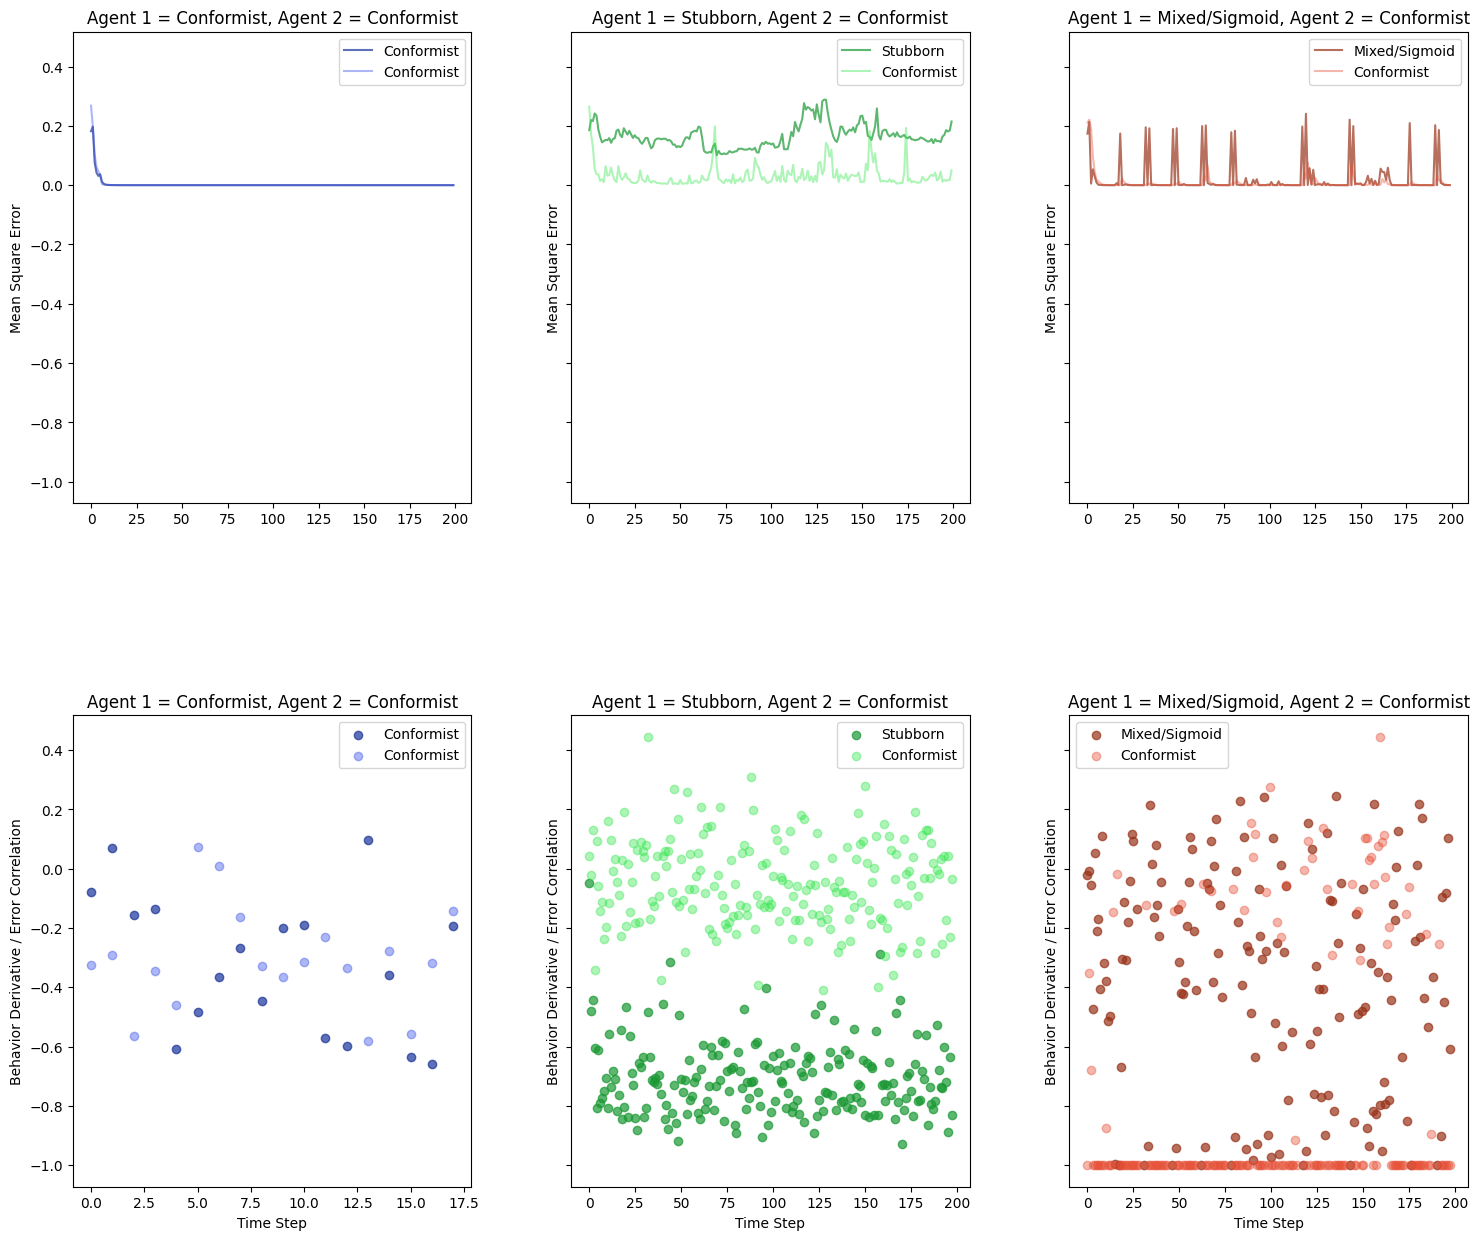

In [348]:
# seed = random.randrange(1000)
seed = 88
# rng = random.Random(seed)
print("Seed was:", seed)
np.random.seed(seed)
w = 6; h = 5
ncols = 3
nrows = 1
param_vals = [i for i in range(0, ncols*nrows)]
tups = list(it.product(range(nrows), range(ncols)))
agents_label = ["Conformist", "Stubborn", "Mixed/Sigmoid"]
agents1 = [conformist2, stubborn, sigmoid]
agents2 = [conformist1, conformist1, conformist1]
fig, ax = plt.subplots(nrows*2, ncols, figsize=(w*ncols, h*nrows*3), dpi=100,
                       sharey=True)#, sharex=True)
plt.subplots_adjust(wspace=0.25,hspace=0.45)
trials = 200
time = [i for i in range(trials)]

color1 = [0.1,0.2,0.6, 0.7]
color1c = [0.2,0.3,0.9, 0.4]
color2 = [0.1,0.6,0.2, 0.7]
color2c = [0.2,0.9,0.3, 0.4]
color3 = [0.6,0.2,0.1, 0.7]
color3c = [0.9,0.3,0.2, 0.4]
colors = [color1,color2,color3]
colors_c = [color1c,color2c,color3c]
color_black = [0.1,0.1,0.1,0.5]

for ix, param in enumerate(param_vals):
    # experiments
    conformist1 = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_true,
    controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
    system_estimate=A1, reference=R1, init_behavior=behav_1)

    conformist2 = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_true,
    controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
    system_estimate=A1, reference=R1, init_behavior=behav_1)

    stubborn = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_false,
    controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B2, 
    system_estimate=A2, reference=R2, init_behavior=behav_2)

    sigmoid = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_sigmoid,
    controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
    system_estimate=A1, reference=R1, init_behavior=behav_1)

    plant1 = Plant(transition_matrix=T1, transition_function=transition, state=np.random.rand(1, behav_size))
    plant2 = Plant(transition_matrix=T2, transition_function=transition, state=np.random.rand(1, behav_size))

    b1 = np.random.rand(1, behav_size)
    b2 = np.random.rand(1, behav_size)

    agent1 = agents1[param%3]
    agent2 = agents2[0]
    agent1_error = []
    agent2_error = []
    agent1_raw_error = []
    agent2_raw_error = []
    sigmoid_value = []
    agent1_behaviors = []
    agent2_behaviors = []
    agent1_control = []
    agent2_control = []
    agent1_reference = []
    agent2_reference = []
    for t in range(trials):
        color1 = [0.1,0.2,0.8, (t+1)/(trials+1)]
        color2 = [0.1,0.8,0.2, (t+1)/(trials+1)]
        #pl.scatter(agent1.get_reference()[0],-0.03, c=color1, edgecolors=[0.8,0.1,0.1, color1[1]])
        #pl.scatter(agent2.get_reference()[0],0, c=color2, edgecolors=[0.8,0.1,0.1, color2[3]], linewidth=1.5)
        b1_control = agent1.go(b2)   
        b2_control = agent2.go(b1)

        agent1_control.append(agent1.get_output())
        agent2_control.append(agent2.get_output())

        b1 = plant1.transition(b1_control)
        b2 = plant2.transition(b2_control)
        
        agent1_behaviors.append(b1)
        agent2_behaviors.append(b2)

        # agent1_error.append(np.absolute(agent1.get_error()))
        # agent2_error.append(np.absolute(agent2.get_error()))
        agent1_raw_error.append(agent1.get_error()[0])
        agent2_raw_error.append(agent2.get_error()[0])
        # if b1[0][0] == 0.0 or b1[0][0] == 1.0:
        #   agent1_raw_error.append(b1[0][0]+0.001)
        # else:
        #   agent1_raw_error.append(agent1.get_error()[0][0])
        # if b2[0][0] == 0.0 or b2[0][0] == 1.0:
        #    agent2_raw_error.append(b2[0][0]+0.001)
        # else:
        #   agent2_raw_error.append(agent2.get_error()[0][0])
        
        agent1_error.append(np.sum(np.square(agent1.get_error()[0]))/len(agent1.get_error()[0]))
        agent2_error.append(np.sum(np.square(agent2.get_error()[0]))/len(agent2.get_error()[0]))
        if agents_label[param] == "Mixed/Sigmoid": 
          sqr_error = np.square(agent2.get_error()[0])
          sigmoid_value.append(shifted_sigmoid(sqr_error, sigmoid_k, sigmoid_b))

        agent1_reference.append(agent1.get_reference()[0])
        agent2_reference.append(agent2.get_reference()[0])

    ai = tups[ix]
    color = colors[param]
    color_c = colors_c[param]
    # plots
    ax[ai].plot(time, agent1_error, color=color, label=agents_label[param])
    ax[ai].plot(time, agent2_error, color=color_c, label="Conformist")
    # if agents_label[param] == "Mixed/Sigmoid": 
    #   ax[ai].plot(time, sigmoid_value, color=color_black, label="Sigmoid Strategy")
    #   print(sigmoid_value)
    ax[ai].set_title('Agent 1 = {}, Agent 2 = Conformist'.format(agents_label[param%3]))
    ax[ai].legend()
    # ax[ai].set_xlim(0,t)
    # ax[ai].set_ylim(0,1)
    ax[ai].tick_params(axis='x')
    ax[ai].tick_params(axis='y')
    ax[ai].set_ylabel("Mean Square Error")
    # ax[ai].set_xlabel("Time Step")

    # derivative charts
    dx = 1
    # b1_flat = [i[0] for i in agent1_control]
    # b2_flat = [i[0] for i in agent2_control]
    b1_flat = [i[0]for i in agent1_behaviors]
    # print("ag 1 behaviors: ", agent1_behaviors)
    # print("ag 1 flat behaviors: ", b1_flat)
    b2_flat = [i[0]for i in agent2_behaviors]
    # d_behav1 = abs(np.gradient(b1_flat, dx))
    # d_behav2 = abs(np.gradient(b2_flat, dx))
    # d_behav1 = np.insert(np.diff(b1_flat, dx), 0, 0)
    d_behav1 = matrix_deriv(np.array(b1_flat), behav_size, trials)[:-1]
    # print("ag 1 behav deriv: ", d_behav1)
    # d_behav2 = np.insert(np.diff(b2_flat, dx), 0, 0)
    d_behav2 = matrix_deriv(np.array(b2_flat), behav_size, trials)[:-1]
    # print("agent1_raw_error: ", agent1_raw_error)
    # agent1_raw_error.insert(-1, 1)
    # print("agent1_raw_error inserted: ", agent1_raw_error)
    # agent2_raw_error.insert(-1, 1)
    agent1_raw_error_shifted = agent1_raw_error[2:]
    agent2_raw_error_shifted = agent2_raw_error[2:]

    # print(agents_label[param%3], "ratio: ", np.average(abs(d_behav1/agent2_raw_error_shifted)))
    # print(agents_label[0], "ratio: ", np.average(abs(d_behav2/agent1_raw_error_shifted)))
    # print(agents_label[param%3], "+ Conformist covariance:", np.cov(np.absolute(d_behav1), np.absolute(agent2_raw_error_shifted)))
    # print(agents_label[0], "&",agents_label[param%3], "covariance:", np.cov(np.absolute(d_behav2), np.absolute(agent1_raw_error_shifted)))
    # print(agents_label[param%3], "& Conformist Pearson R:", np.corrcoef(np.absolute(d_behav1), np.absolute(agent2_raw_error_shifted))[0][1])
    # print(agents_label[0], "&", agents_label[param%3], " Pearson R:", np.corrcoef(np.absolute(d_behav2), np.absolute(agent1_raw_error_shifted))[0][1])
    # print("---")

    # print(agents_label[param])
    # print("error: ", agent2_raw_error_shifted)
    # print("d_behav: ", d_behav1)
    coef1 = [np.corrcoef(d_behav1[i], agent2_raw_error_shifted[i])[0][1] for i in range(len(d_behav1))]
    # print(coef1)
    coef2 = [np.corrcoef(d_behav2[i], agent1_raw_error_shifted[i])[0][1] for i in range(len(d_behav2))]
    
    ax[(ai[0]+1,ai[1])].scatter([ i for i in range(trials-2)], coef1, color=color, label="{}".format(agents_label[param]))
    # ax[(ai[0]+1,ai[1])].scatter(np.absolute(d_behav1), np.absolute(agent2_raw_error_shifted), color=color, label="{}".format(agents_label[param]))
    ax[(ai[0]+1,ai[1])].scatter([ i for i in range(trials-2)], coef2, color=color_c, label="Conformist")
    # ax[(ai[0]+1,ai[1])].scatter(np.absolute(d_behav2), np.absolute(agent1_raw_error_shifted), color=color_c, label="Conformist")

    ax[(ai[0]+1,ai[1])].set_title('Agent 1 = {}, Agent 2 = Conformist'.format(agents_label[param%3]))
    ax[(ai[0]+1,ai[1])].legend()
    # ax[ai].set_ylim(0,1)
    # ax[ai].set_xlim(0,t)
    # ax[(ai[0]+1,ai[1])].set_ylim(0,5)
    ax[(ai[0]+1,ai[1])].tick_params(axis='x')
    ax[(ai[0]+1,ai[1])].tick_params(axis='y')
    ax[(ai[0]+1,ai[1])].set_ylabel("Behavior Derivative / Error Correlation")
    ax[(ai[0]+1,ai[1])].set_xlabel("Time Step")

plt.show()

### Show That Sigmoid Agent Can Mimic Conformist 

In [379]:
# seed = random.randrange(1000)
seed = 22
np.random.seed(seed)
print("Seed was:", seed)

behav_size = 1
sigmoid_k = 99999
sigmoid_b = -5
# behavioral matrix (maps previous behavior to future behavior commands - how should I behave?)
# behavioral matrix (maps previous behavior to future behavior commands - how should I behave?)
B1 = np.random.rand(1, behav_size)
B2 = np.random.rand(1, behav_size)

# state/system matrix (maps previous state to future state - how will others behave (give past behaviors)?)
A1 = np.random.rand(1, behav_size)
A2 = np.random.rand(1, behav_size)

# reference matrix (how do I expect/want others to behave? target values)
R1 = np.random.rand(1, behav_size)
R2 = np.random.rand(1, behav_size)

# Initial behavior
behav_1 = np.random.rand(1, behav_size)
behav_2 = np.random.rand(1, behav_size)

# transition matrix (maps control signal and previous state to current state - what behaviors do I enact given my intentions?)
T1 = np.array([0.2])
T2 = np.array([0.2])

color2 = [0.1,0.6,0.2, 0.7]
color2c = [0.2,0.9,0.3, 0.4]

# get the state observation (behaviors of others)
def sense(inputs):
    perception = inputs
    return perception

# contrast reference with observations (and potentially incorporate predictions from internal model)
def compare(sensory_signal, reference, prediction):
    error = reference - sensory_signal
    return error

# generate a control signal
def control(error, behavioral_model, previous_output):
    control_signal = chaotic_controller(behavioral_model, 0.01, error)
    return control_signal

# dictates how control commands determine state transitions - i.e. behaviors
def transition(control_signal, transition_matrix, state):
    new_state = (transition_matrix * control_signal) + state
    new_state[new_state > 1] = 1
    new_state[new_state < 0] = 0
    return new_state


# adjusts behavioral model to get closer to behavior given 
def control_update(error, behavioral_model, previous_output):
    # LMS algorithm
    learning_rate = 0.0
    #behavioral_model = behavioral_model + learning_rate * error * previous_output
    return behavioral_model

# adjusts reference given error
def reference_update_true(reference, error):
    k = 0.2
    reference = reference - (error * k)
    reference[reference > 1] = 1
    reference[reference < 0] = 0
    return reference

# does not adjust reference
def reference_update_false(reference, error):
    k = 0
    reference = reference + (error * k)
    return reference

def reference_update_sigmoid(reference, error):
    # reference = (matrix_sigmoid(error)-1)*(R1) + matrix_sigmoid(error)*(reference + error)
    sqr_error = np.square(error)
    reference = shifted_sigmoid(sqr_error, sigmoid_k, sigmoid_b)*(reference - error) + (1-shifted_sigmoid(sqr_error, sigmoid_k, sigmoid_b))*(R1)
    # k = 0.1
    # k =  zero_sigmoid(error)
    # reference = reference - (error * k)
    return reference

# generate predictions on next state
def imc(system_estimate, previous_state, behavioral_model, previous_output):
    # actual estimate
    state = (system_estimate * previous_state) + (behavioral_model * previous_output)
    return state

# adjust system estimate to infer observations given my behavior
def imc_update(inputs, system_estimate, previous_behavior, behavioral_model, previous_state, learning_rate):
    # actual estimate
    #curr_system_est = (system_estimate @ previous_state) + (behavioral_model @ previous_behavior)
    #error = curr_system_est - inputs
    #learning_rate = 0.01
    #system_estimate = system_estimate + learning_rate * error * previous_behavior
    return system_estimate

plant1 = Plant(transition_matrix=T1, transition_function=transition, state=behav_1)
plant2 = Plant(transition_matrix=T2, transition_function=transition, state=behav_2)

conformist1 = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_true,
controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
system_estimate=A1, reference=R1, init_behavior=behav_1)

conformist2 = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_true,
controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
system_estimate=A1, reference=R1, init_behavior=behav_1)

stubborn = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_false,
controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B2, 
system_estimate=A2, reference=R2, init_behavior=behav_2)

sigmoid = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_sigmoid,
controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
system_estimate=A1, reference=R1, init_behavior=behav_1)

Seed was: 22


Seed was: 159

 Sigmoid Model Agents (Error Relative to Expectation)


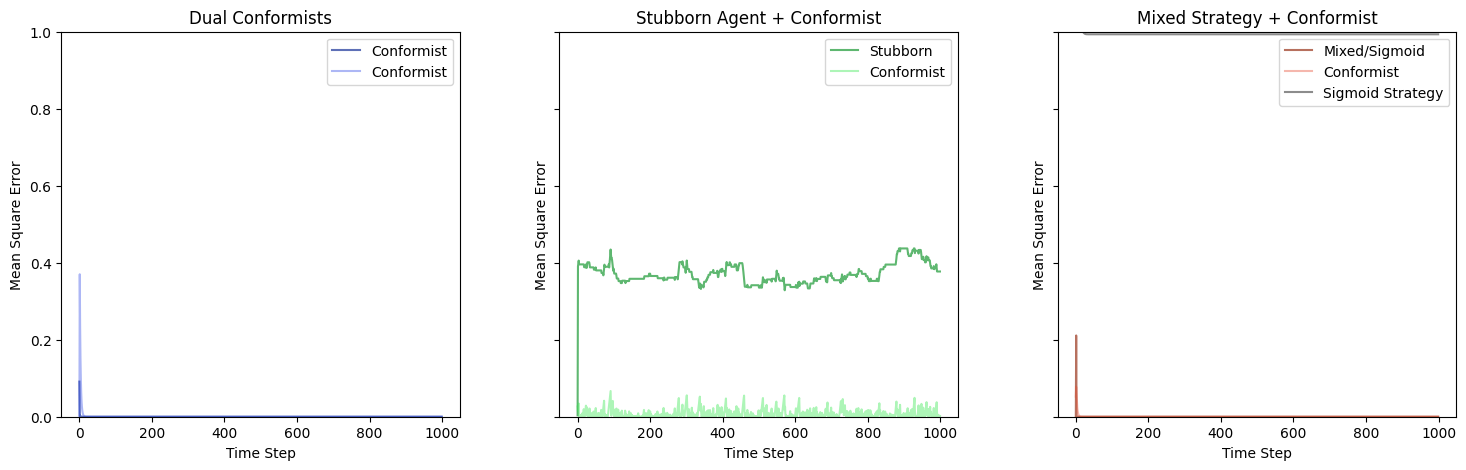

In [380]:
seed = random.randrange(1000)
# seed = 14
np.random.seed(seed)
print("Seed was:", seed)
w = 6; h = 5
ncols = 3
nrows = 1
param_vals = [i for i in range(0, ncols*nrows)]
tups = list(it.product(range(nrows), range(ncols)))
agents_label = ["Conformist", "Stubborn", "Mixed/Sigmoid"]
agents1 = [conformist2, stubborn, sigmoid]
agents2 = [conformist1, conformist1, conformist1]
fig, ax = plt.subplots(nrows, ncols, figsize=(w*ncols, h*nrows), dpi=100,
                       sharey=True)#, sharex=True)
plt.subplots_adjust(wspace=0.25,hspace=0.45)
trials = 1000
time = [i for i in range(trials)]

color1 = [0.1,0.2,0.6, 0.7]
color1c = [0.2,0.3,0.9, 0.4]
color2 = [0.1,0.6,0.2, 0.7]
color2c = [0.2,0.9,0.3, 0.4]
color3 = [0.6,0.2,0.1, 0.7]
color3c = [0.9,0.3,0.2, 0.4]
colors = [color1,color2,color3]
colors_c = [color1c,color2c,color3c]
color_black = [0.1,0.1,0.1,0.5]

for ix, param in enumerate(param_vals):
    # experiments
    conformist1 = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_true,
    controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
    system_estimate=A1, reference=R1, init_behavior=behav_1)

    conformist2 = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_true,
    controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
    system_estimate=A1, reference=R1, init_behavior=behav_1)

    stubborn = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_false,
    controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B2, 
    system_estimate=A2, reference=R2, init_behavior=behav_2)

    sigmoid = Control_node(sensor=sense, comparator=compare, control_update=control_update, reference_update=reference_update_sigmoid,
    controller = control, internal_model=imc, internal_model_update=imc_update, behavioral_model=B1, 
    system_estimate=A1, reference=R1, init_behavior=behav_1)

    plant1 = Plant(transition_matrix=T1, transition_function=transition, state=np.random.rand(1, behav_size))
    plant2 = Plant(transition_matrix=T2, transition_function=transition, state=np.random.rand(1, behav_size))

    b1 = np.random.rand(1, behav_size)
    b2 = np.random.rand(1, behav_size)

    agent1 = agents1[param%3]
    agent2 = agents2[0]
    agent1_error = []
    agent2_error = []
    sigmoid_value = []
    for t in range(trials):
        color1 = [0.1,0.2,0.8, (t+1)/(trials+1)]
        color2 = [0.1,0.8,0.2, (t+1)/(trials+1)]
        #pl.scatter(agent1.get_reference()[0],-0.03, c=color1, edgecolors=[0.8,0.1,0.1, color1[1]])
        #pl.scatter(agent2.get_reference()[0],0, c=color2, edgecolors=[0.8,0.1,0.1, color2[3]], linewidth=1.5)
        b1_control = agent1.go(b2)   
        b2_control = agent2.go(b1)

        # agent1_control.append(agent1.get_output())
        # agent2_control.append(agent2.get_output())

        b1 = plant1.transition(b1_control)
        b2 = plant2.transition(b2_control)
        
        # agent1_behaviors.append(b1)
        # agent2_behaviors.append(b2)

        # agent1_error.append(np.absolute(agent1.get_error()))
        # agent2_error.append(np.absolute(agent2.get_error()))
        agent1_error.append(np.sum(np.square(agent1.get_error()[0]))/len(agent1.get_error()[0]))
        agent2_error.append(np.sum(np.square(agent2.get_error()[0]))/len(agent2.get_error()[0]))
        if agents_label[param] == "Mixed/Sigmoid": 
          sqr_error = np.square(agent2.get_error()[0])
          sigmoid_value.append(shifted_sigmoid(sqr_error, sigmoid_k, sigmoid_b))

        # agent1_reference.append(agent1.get_reference()[0])
        # agent2_reference.append(agent2.get_reference()[0])

    ai = tups[ix][1]
    color = colors[param]
    color_c = colors_c[param]
    # plots
    ax[ai].plot(time, agent1_error, color=color, label=agents_label[param])
    ax[ai].plot(time, agent2_error, color=color_c, label="Conformist")
    if agents_label[param] == "Mixed/Sigmoid": 
      ax[ai].plot(time, sigmoid_value, color=color_black, label="Sigmoid Strategy")
    #   print(sigmoid_value)
    if agents_label[param%3] == "Conformist":
      ax[ai].set_title('Dual Conformists')
    elif agents_label[param%3] == "Stubborn":
      ax[ai].set_title('Stubborn Agent + Conformist')
    else:
      ax[ai].set_title('Mixed Strategy + Conformist')
    ax[ai].legend()
    # ax[ai].set_xlim(0,t)
    ax[ai].set_ylim(0,1)
    ax[ai].tick_params(axis='x')
    ax[ai].tick_params(axis='y')
    ax[ai].set_ylabel("Mean Square Error")
    ax[ai].set_xlabel("Time Step")

print("\n Sigmoid Model Agents (Error Relative to Expectation)")
# print("Agent 1 base reference: {}".format(R1))
# print("Agent 2 base reference: {}".format(R2))
plt.show()

### Scratch Work

In [183]:
# investigating -1 conformist correlations in sigmoid case
print(coef2[54])
print(agent1_raw_error_shifted[54])
print(d_behav2[54])




-1.0
[ 0.01454089 -0.03218108 -0.02313377 -0.00850707 -0.01922031 -0.01679566
  0.01273211 -0.00429548  0.01957796 -0.03047746 -0.02216484 -0.03975788
  0.00681055 -0.01449988 -0.01151191 -0.00864103 -0.02958216  0.00180413
 -0.00221501 -0.02970185  0.00749252  0.01372076  0.01500398 -0.00993083
 -0.02931745 -0.02013294 -0.01334102 -0.01371742 -0.0117961  -0.00565544
  0.00504841 -0.01573635 -0.01987115 -0.0191835  -0.03256478 -0.00899477
 -0.01350633 -0.01004508 -0.02473687  0.00992636 -0.01566465 -0.0193648
 -0.0243776   0.00662096 -0.02030571 -0.02337517 -0.01222031 -0.02276325
 -0.01309425  0.03063215]
[-0.01454089  0.03218108  0.02313377  0.00850707  0.01922031  0.01679566
 -0.01273211  0.00429548 -0.01957796  0.03047746  0.02216484  0.03975788
 -0.00681055  0.01449988  0.01151191  0.00864103  0.02958216 -0.00180413
  0.00221501  0.02970185 -0.00749252 -0.01372076 -0.01500398  0.00993083
  0.02931745  0.02013294  0.01334102  0.01371742  0.0117961   0.00565544
 -0.00504841  0.01573

In [197]:
# investigating -1 conformist correlations in sigmoid case
print(coef1[84:87])
print(agent2_raw_error_shifted[85])
print(d_behav1[85])

[-0.9991014435608242, nan, -0.959678749500367]
[-0.03770918 -0.05964366 -0.05894456 -0.00916881 -0.00847428  0.0004833
 -0.01713752 -0.01971938 -0.11384336 -0.0017065  -0.09880912 -0.03233566
 -0.06434915 -0.06303439 -0.00203614 -0.00427229 -0.01819278 -0.00958058
 -0.0147159   0.00325058 -0.02329864 -0.03354375 -0.03235218 -0.07154833
 -0.08456604 -0.07224736 -0.00815107 -0.0904591  -0.08294256 -0.02042623
 -0.04912403 -0.05699172 -0.02419513 -0.0166227  -0.08161547 -0.06186383
 -0.04022385 -0.05988196 -0.10868714 -0.01317207 -0.09369284 -0.00925103
 -0.06266531 -0.06732191 -0.06723726 -0.02016818 -0.09947293 -0.00696132
 -0.10028535 -0.09641529]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
